# Lab 5 – Hyperspectral Water Quality Analysis & Sentinel-2 Comparison

**Area:** Odra (Oder) River, Poland  
**Sensor:** Airborne hyperspectral (VNIR+SWIR, 456 bands, 414–2000 nm, 1 m GSD)  
**Projection:** ETRS89 / CS2000 Zone 6 (EPSG:2177)  

## Workflow
1. False-colour composites from the hyperspectral data cube
2. Water quality indices (Chl-a, DOC/CDOM, turbidity) from airborne data
3. Download the closest cloud-free Sentinel-2 scene via Planetary Computer
4. Calculate the same water quality indices for Sentinel-2
5. Qualitative and quantitative comparison

## 0. Setup

In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

import spectral.io.envi as envi
import rasterio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.crs import CRS
import pyproj
from pyproj import Transformer
from shapely.geometry import box, mapping

import pystac_client
import planetary_computer
import requests
import io

matplotlib.rcParams['figure.dpi'] = 110
matplotlib.rcParams['axes.titlesize'] = 11

# ── paths ─────────────────────────────────────────────────────────────────────
DATA_DIR = Path('data/Obrazy lotnicze')
OUT_DIR  = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

HDR_FILES = {
    'block_008': DATA_DIR / '221000_Odra_HS_Blok_A_008_VS_join_atm.hdr',
    'block_013': DATA_DIR / '221000_Odra_HS_Blok_A_013_VS_join_atm.hdr',
    'block_015': DATA_DIR / '221000_Odra_HS_Blok_A_015_VS_join_atm.hdr',
}

SCALE_FACTOR   = 10_000.0   # stored value = reflectance_fraction * 10000
IGNORE_VALUE   = 15_000.0   # no-data sentinel in raw data
EPSG_LOCAL     = 2177       # ETRS89 / Poland CS2000 Zone 6

# ── acquisition date estimate (update if exact date is known) ─────────────────
# This is used to search for temporally close Sentinel-2 imagery.
ACQUISITION_DATE = '2022-08-15'   # ← adjust to actual flight date
SEARCH_WINDOW_DAYS = 30           # search ± N days around the acquisition date

print('Setup complete.')

Setup complete.


## 1. Load Hyperspectral Data

In [3]:
def load_envi(hdr_path: Path):
    """Open an ENVI header and return (image_object, metadata_dict)."""
    img  = envi.open(str(hdr_path))
    meta = img.metadata
    return img, meta


def get_wavelengths(meta: dict) -> np.ndarray:
    wl = meta.get('wavelength')
    if wl is None:
        raise ValueError('No wavelength information in header.')
    return np.array([float(w) for w in wl])


def find_band(target_nm: float, wavelengths: np.ndarray) -> int:
    """Return the 0-based band index closest to target_nm."""
    return int(np.argmin(np.abs(wavelengths - target_nm)))


def get_map_origin(meta: dict) -> tuple[float, float]:
    """Return (easting, northing) of the upper-left pixel centre (CS2000 Zone 6)."""
    map_info = meta['map info']
    # spectral returns multi-value ENVI fields as Python lists
    if isinstance(map_info, list):
        parts = [p.strip() for p in map_info]
    else:
        parts = [p.strip() for p in str(map_info).strip('{}').split(',')]
    # Format: [projection, ref_col, ref_row, easting, northing, dx, dy, ...]
    easting  = float(parts[3])
    northing = float(parts[4])
    return easting, northing


def read_band_as_reflectance(img, band_idx: int) -> np.ndarray:
    """Read a single band; apply mask & scale to fractional reflectance."""
    data = img.read_bands([band_idx]).squeeze().astype(np.float32)
    data = np.where((data >= IGNORE_VALUE) | (data < 0), np.nan, data)
    return data / SCALE_FACTOR


def read_multi_bands(img, band_indices: list[int]) -> np.ndarray:
    """Read multiple bands; returns (H, W, N) array of fractional reflectance."""
    data = img.read_bands(band_indices).astype(np.float32)
    data = np.where((data >= IGNORE_VALUE) | (data < 0), np.nan, data)
    return data / SCALE_FACTOR


# ── load all three blocks ─────────────────────────────────────────────────────
blocks = {}
for name, hdr in HDR_FILES.items():
    img, meta = load_envi(hdr)
    wl         = get_wavelengths(meta)
    origin     = get_map_origin(meta)
    blocks[name] = dict(img=img, meta=meta, wl=wl, origin=origin)
    print(f'{name}: {img.nrows} rows × {img.ncols} cols × {img.nbands} bands  '
          f'| λ {wl[0]:.0f}–{wl[-1]:.0f} nm  '
          f'| origin E={origin[0]:.0f} N={origin[1]:.0f}')

block_008: 4300 rows × 2001 cols × 456 bands  | λ 414–2499 nm  | origin E=6509736 N=5580712
block_013: 1800 rows × 4324 cols × 456 bands  | λ 414–2499 nm  | origin E=6510302 N=5581560
block_015: 2838 rows × 3862 cols × 456 bands  | λ 414–2499 nm  | origin E=6517216 N=5581457


In [4]:
# ── print key band positions for the first block (all share same wavelengths) ─
wl = blocks['block_008']['wl']

targets = {
    'Blue (B02)':      443,
    'Green (B03)':     560,
    'Red (B04)':       665,
    'Red Edge 1 (B05)':709,
    'Red Edge 2 (B06)':740,
    'Red Edge 3 (B07)':783,
    'NIR (B08)':       842,
    'SWIR1 (B11)':    1610,
}

print(f'{'Band':<22} {'Target (nm)':>11}  {'Nearest (nm)':>12}  {'Index':>6}')
print('-' * 56)
for label, target in targets.items():
    idx = find_band(target, wl)
    print(f'{label:<22} {target:>11.0f}  {wl[idx]:>12.2f}  {idx:>6}')

Band                   Target (nm)  Nearest (nm)   Index
--------------------------------------------------------
Blue (B02)                     443        442.90       9
Green (B03)                    560        561.17      46
Red (B04)                      665        663.46      78
Red Edge 1 (B05)               709        708.21      92
Red Edge 2 (B06)               740        740.18     102
Red Edge 3 (B07)               783        781.74     115
NIR (B08)                      842        842.47     134
SWIR1 (B11)                   1610       1612.08     292


## 2. False-Colour Composites

We display four composites for each flight block:

| Composite | R | G | B | Purpose |
|-----------|---|---|---|---------|
| Natural colour | 660 nm | 560 nm | 490 nm | Approximate true colour |
| CIR (Colour InfraRed) | 780 nm | 660 nm | 560 nm | Vegetation health |
| Water enhancement | 709 nm | 600 nm | 500 nm | Highlights chl-a / turbidity in water |
| SWIR composite | 1610 nm | 780 nm | 660 nm | Water body delineation |

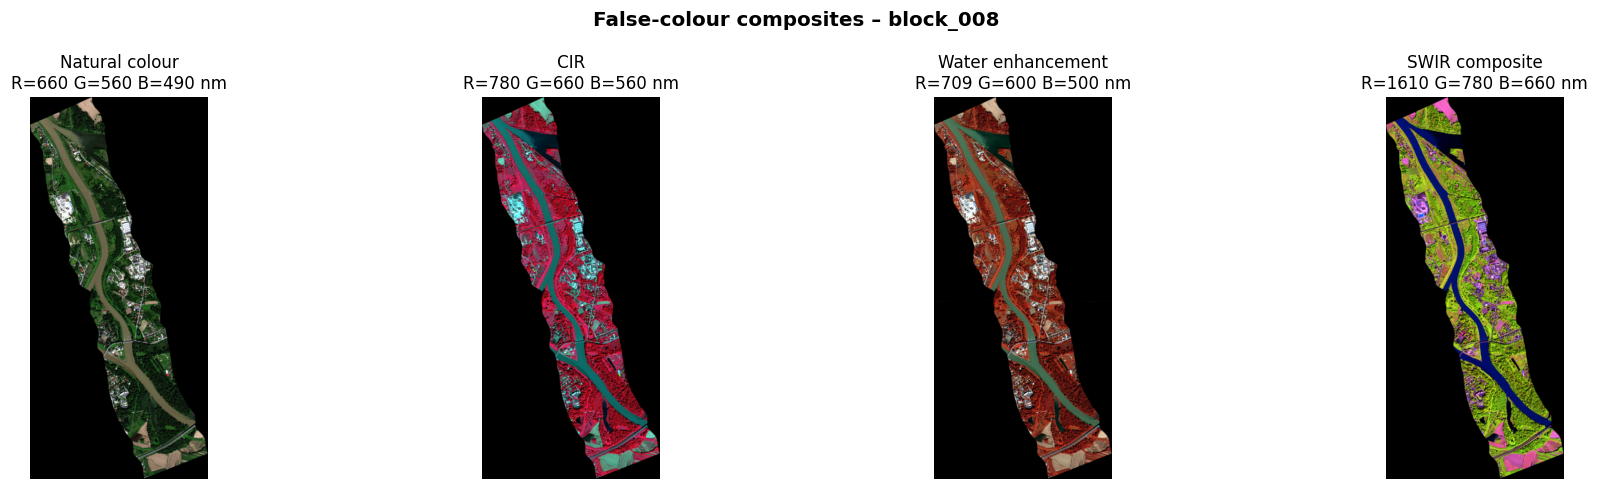

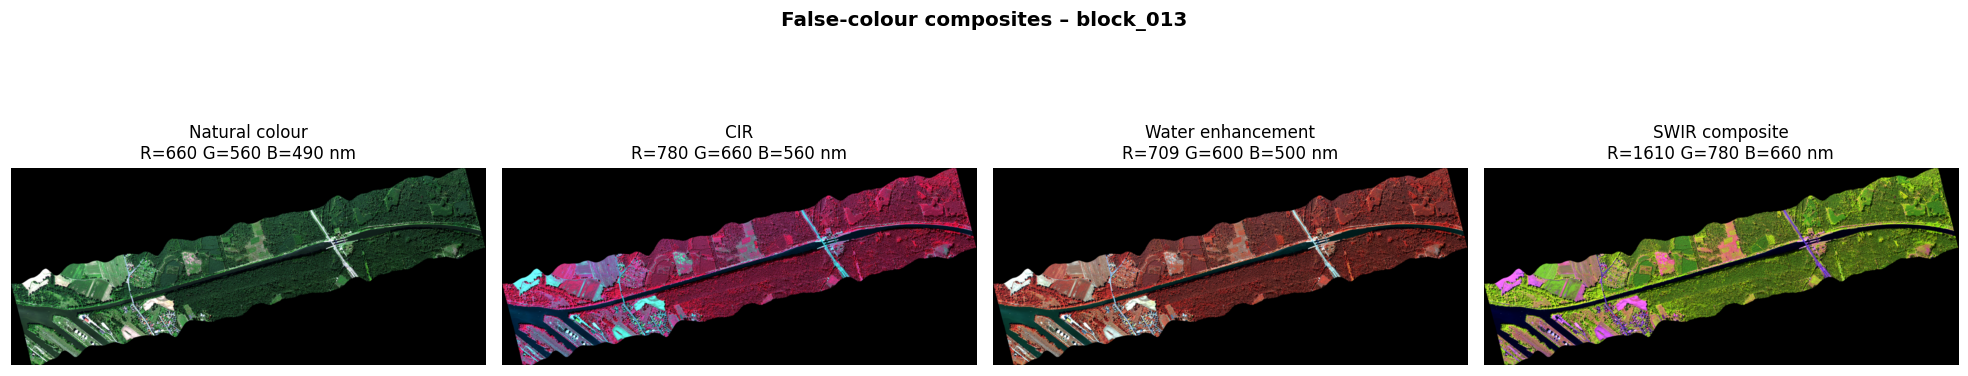

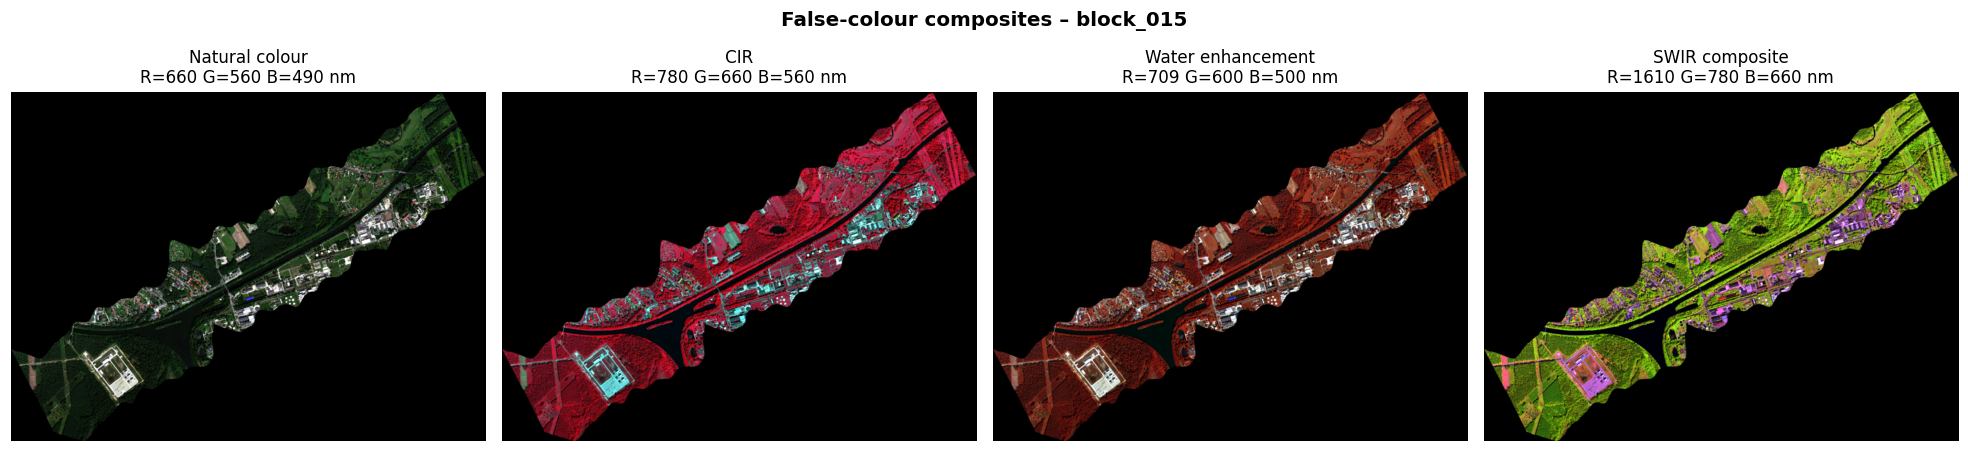

In [5]:
def make_rgb(img, wl, r_nm, g_nm, b_nm, clip_pct=(2, 98)) -> np.ndarray:
    """Read three bands and stretch to [0,1] for display."""
    bands = [find_band(r_nm, wl), find_band(g_nm, wl), find_band(b_nm, wl)]
    cube  = read_multi_bands(img, bands)  # (H, W, 3)
    out   = np.zeros_like(cube)
    for c in range(3):
        ch = cube[:, :, c]
        lo, hi = np.nanpercentile(ch, clip_pct)
        out[:, :, c] = np.clip((ch - lo) / max(hi - lo, 1e-9), 0, 1)
    return np.nan_to_num(out, nan=0.0)


COMPOSITES = [
    ('Natural colour',    660, 560, 490),
    ('CIR',              780, 660, 560),
    ('Water enhancement', 709, 600, 500),
    ('SWIR composite',   1610, 780, 660),
]

for block_name, block in blocks.items():
    img = block['img']
    wl  = block['wl']

    fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
    fig.suptitle(f'False-colour composites – {block_name}', fontsize=13, fontweight='bold')

    for ax, (title, r, g, b) in zip(axes, COMPOSITES):
        rgb = make_rgb(img, wl, r, g, b)
        ax.imshow(rgb, interpolation='bilinear')
        ax.set_title(f'{title}\nR={r} G={g} B={b} nm')
        ax.axis('off')

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'composites_{block_name}.png', bbox_inches='tight', dpi=130)
    plt.show()

## 3. Water Mask

Water strongly absorbs NIR radiation. We threshold the NIR band (≈ 780 nm) to isolate river pixels.  
An additional NDWI > 0 check removes mixed/shadow pixels.

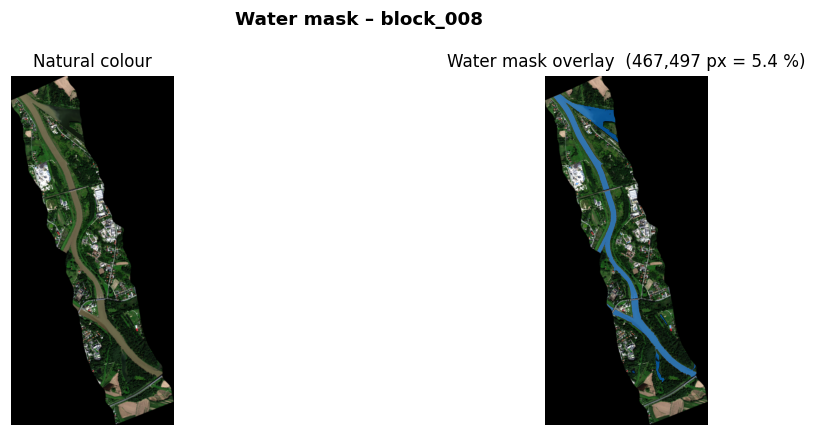

block_008: 467,497 water pixels (5.4 % of image)


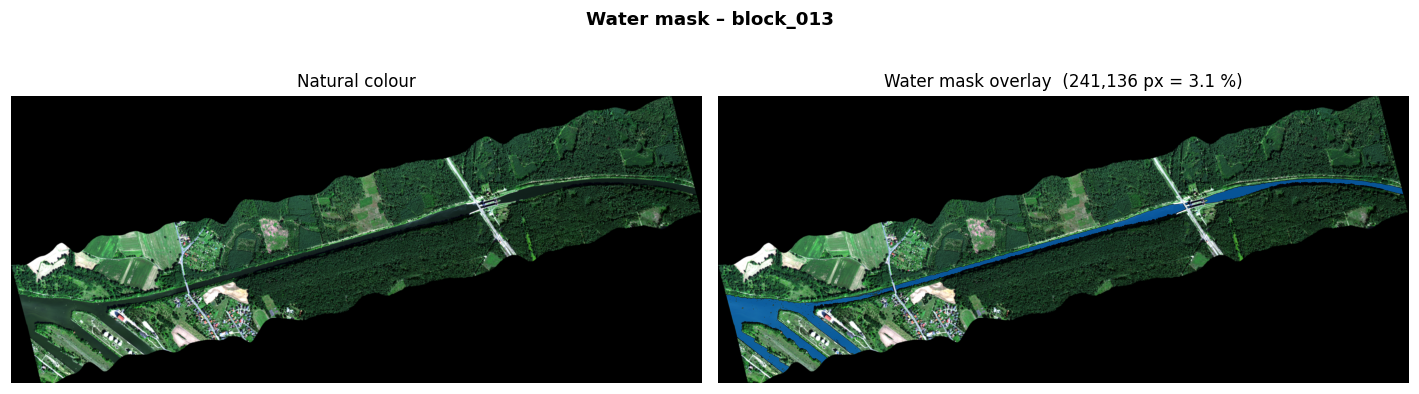

block_013: 241,136 water pixels (3.1 % of image)


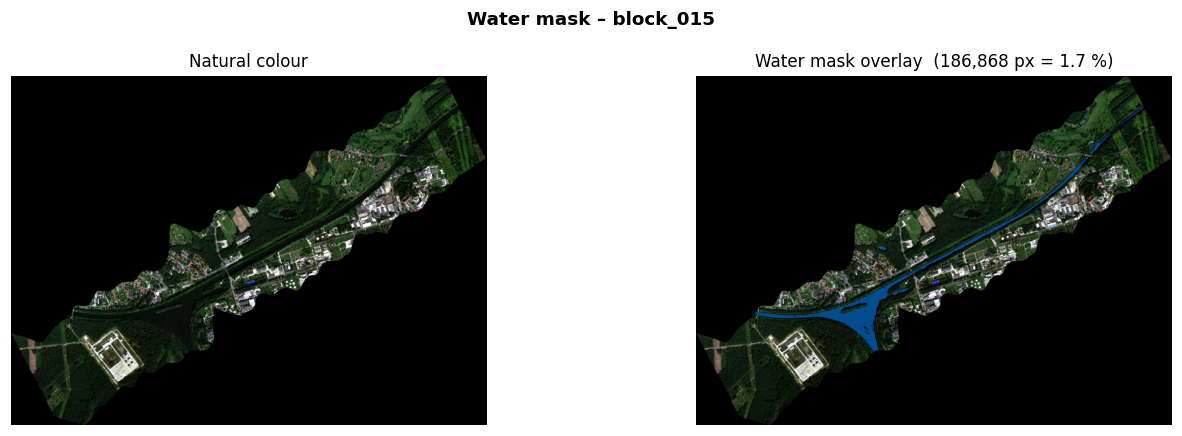

block_015: 186,868 water pixels (1.7 % of image)


In [6]:
def make_water_mask(img, wl,
                    nir_nm=780, green_nm=560,
                    nir_threshold=0.05) -> np.ndarray:
    """
    Returns boolean mask: True = water pixel.
    Criteria:
      1) NIR reflectance < nir_threshold  (water absorbs NIR)
      2) NDWI > 0  i.e. Green > NIR
    """
    nir   = read_band_as_reflectance(img, find_band(nir_nm,   wl))
    green = read_band_as_reflectance(img, find_band(green_nm, wl))

    ndwi = (green - nir) / (green + nir + 1e-9)

    mask = (nir < nir_threshold) & (ndwi > 0) & np.isfinite(nir)
    return mask


for block_name, block in blocks.items():
    mask = make_water_mask(block['img'], block['wl'])
    block['water_mask'] = mask

    rgb = make_rgb(block['img'], block['wl'], 660, 560, 490)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Water mask – {block_name}', fontweight='bold')

    ax1.imshow(rgb, interpolation='bilinear')
    ax1.set_title('Natural colour')
    ax1.axis('off')

    ax2.imshow(rgb, interpolation='bilinear')
    water_overlay = np.zeros((*mask.shape, 4), dtype=np.float32)
    water_overlay[mask] = [0.0, 0.5, 1.0, 0.55]
    ax2.imshow(water_overlay)
    ax2.set_title(f'Water mask overlay  ({mask.sum():,} px = {mask.mean()*100:.1f} %)')
    ax2.axis('off')

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'water_mask_{block_name}.png', bbox_inches='tight', dpi=130)
    plt.show()
    print(f'{block_name}: {mask.sum():,} water pixels ({mask.mean()*100:.1f} % of image)')

## 4. Water Quality Indices – Airborne Hyperspectral

### 4a. Chlorophyll-a

**NDCI** (Normalised Difference Chlorophyll Index, Mishra & Mishra 2012):  
$$\mathrm{NDCI} = \frac{R_{709} - R_{665}}{R_{709} + R_{665}}$$

**3-Band algorithm** (Gitelson et al. 2008):  
$$\mathrm{3BA} = \left(\frac{1}{R_{665}} - \frac{1}{R_{709}}\right) \times R_{754}$$

### 4b. DOC / CDOM proxy

CDOM (coloured dissolved organic matter, proxy for DOC) strongly absorbs blue light. A high Blue/Red ratio indicates low CDOM; a low ratio (blue absorbed) indicates high CDOM/DOC.  
$$\mathrm{CDOM\_proxy} = \frac{R_{443}}{R_{665}}$$
(lower value → higher CDOM / DOC)

### 4c. Turbidity (Suspended Particulate Matter proxy)

**NDTI** (Normalised Difference Turbidity Index, Lacaux et al. 2007):  
$$\mathrm{NDTI} = \frac{R_{665} - R_{560}}{R_{665} + R_{560}}$$
Higher values indicate more suspended matter (water appears reddish).

In [7]:
def compute_indices_hs(img, wl) -> dict[str, np.ndarray]:
    """Compute water quality indices from hyperspectral data cube."""
    R443 = read_band_as_reflectance(img, find_band(443, wl))
    R560 = read_band_as_reflectance(img, find_band(560, wl))
    R665 = read_band_as_reflectance(img, find_band(665, wl))
    R709 = read_band_as_reflectance(img, find_band(709, wl))
    R754 = read_band_as_reflectance(img, find_band(754, wl))

    # Chl-a NDCI
    ndci = (R709 - R665) / (R709 + R665 + 1e-9)

    # Chl-a 3-band
    ba3  = (1.0 / (R665 + 1e-9) - 1.0 / (R709 + 1e-9)) * R754

    # DOC / CDOM proxy
    cdom = R443 / (R665 + 1e-9)

    # Turbidity NDTI
    ndti = (R665 - R560) / (R665 + R560 + 1e-9)

    return dict(ndci=ndci, ba3=ba3, cdom=cdom, ndti=ndti)


for block_name, block in blocks.items():
    indices = compute_indices_hs(block['img'], block['wl'])
    block['hs_indices'] = indices

print('Indices computed for all blocks.')

Indices computed for all blocks.


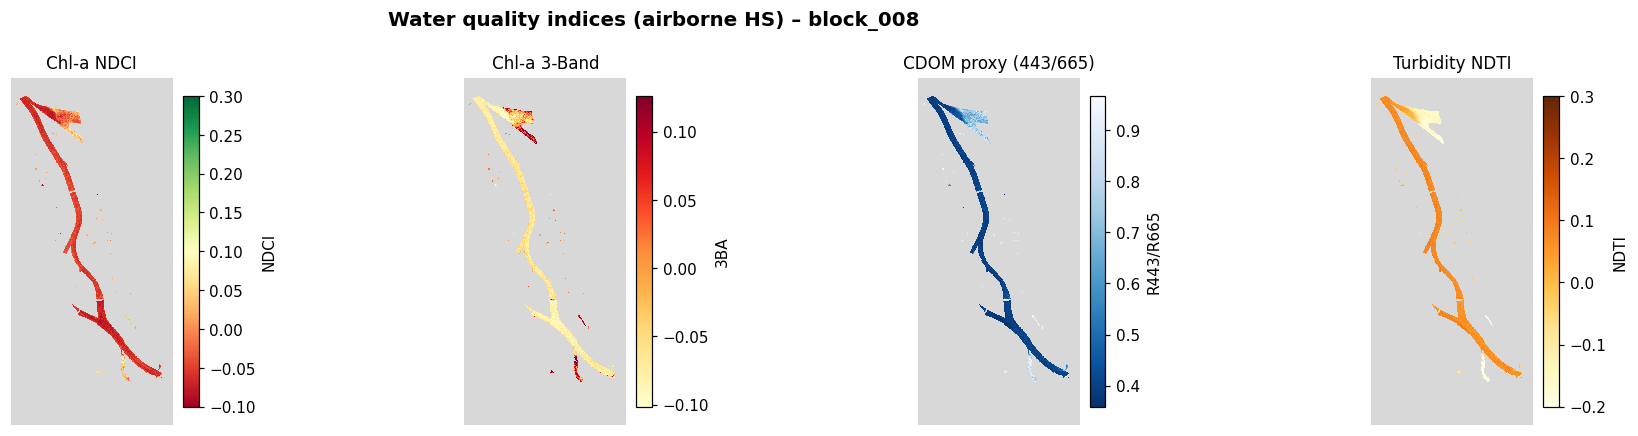

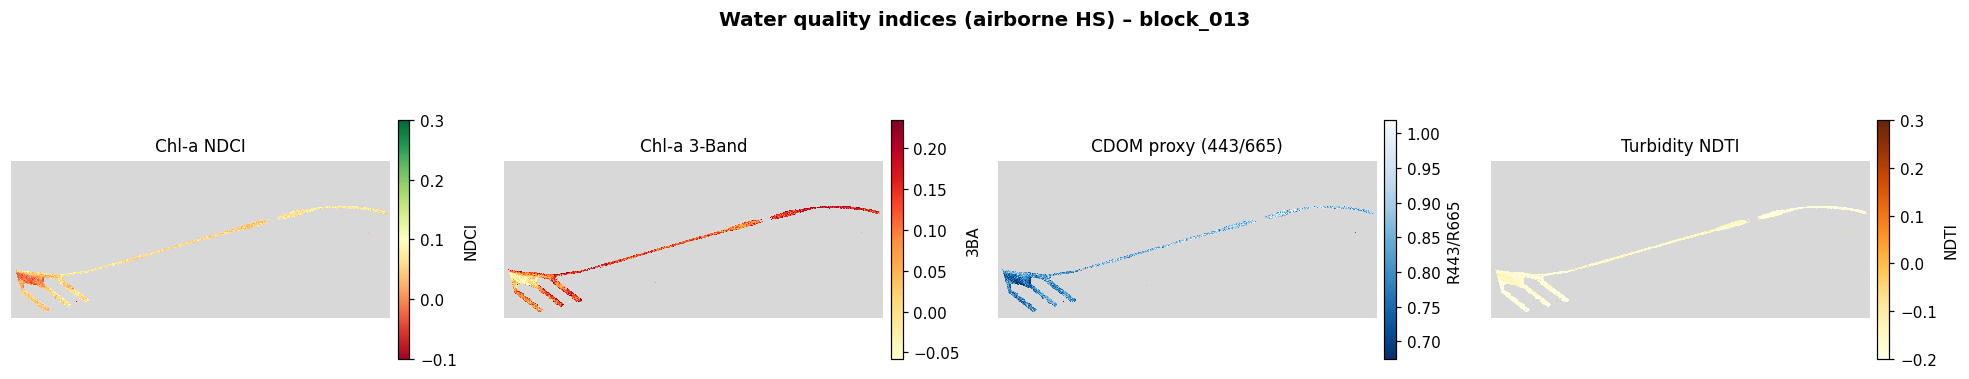

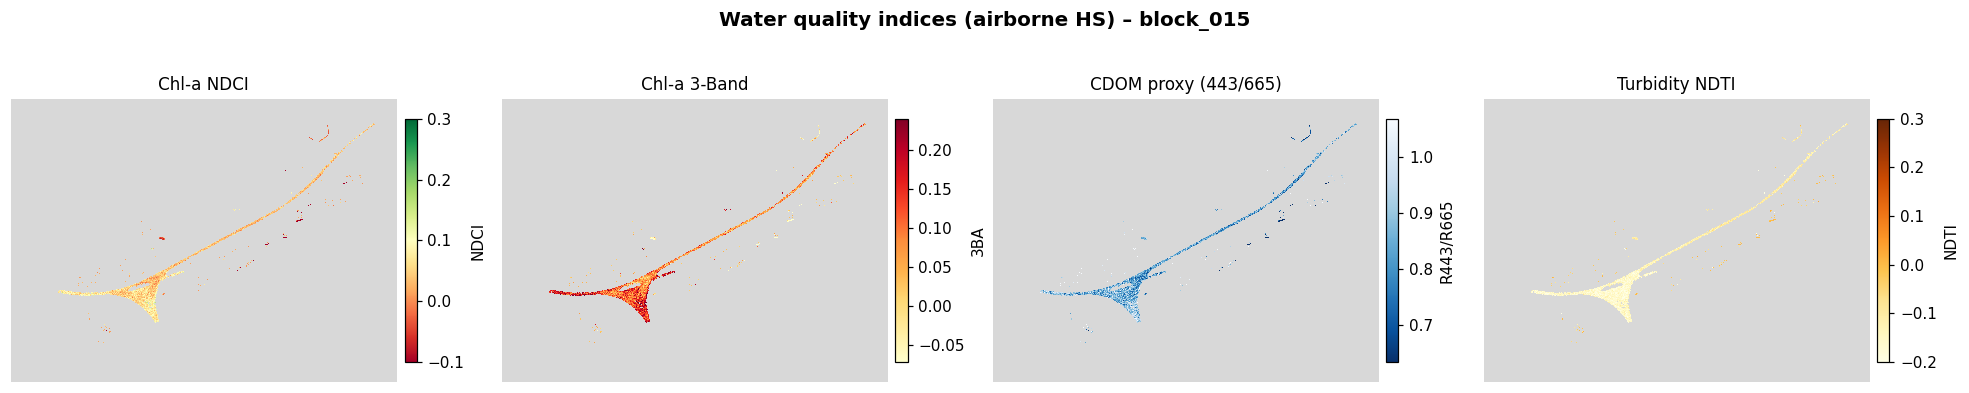

In [8]:
def plot_index_map(ax, data, mask, title, cmap='RdYlGn', vmin=None, vmax=None,
                   cbar_label=''):
    """Display an index map with water mask and colour bar."""
    display = np.where(mask, data, np.nan)
    if vmin is None:
        vmin = np.nanpercentile(display, 2)
    if vmax is None:
        vmax = np.nanpercentile(display, 98)

    bg = np.ones((*mask.shape, 3)) * 0.85   # light grey background
    ax.imshow(bg)
    im = ax.imshow(display, cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label=cbar_label)
    ax.set_title(title)
    ax.axis('off')


INDEX_CONFIGS = [
    ('ndci', 'Chl-a NDCI',          'RdYlGn',   -0.1, 0.3,  'NDCI'),
    ('ba3',  'Chl-a 3-Band',        'YlOrRd',   None, None,  '3BA'),
    ('cdom', 'CDOM proxy (443/665)', 'Blues_r',  None, None,  'R443/R665'),
    ('ndti', 'Turbidity NDTI',       'YlOrBr',  -0.2, 0.3,  'NDTI'),
]

for block_name, block in blocks.items():
    indices = block['hs_indices']
    mask    = block['water_mask']

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    fig.suptitle(f'Water quality indices (airborne HS) – {block_name}',
                 fontsize=13, fontweight='bold')

    for ax, (key, title, cmap, vmin, vmax, clabel) in zip(axes, INDEX_CONFIGS):
        plot_index_map(ax, indices[key], mask, title, cmap, vmin, vmax, clabel)

    fig.tight_layout()
    fig.savefig(OUT_DIR / f'wq_indices_hs_{block_name}.png', bbox_inches='tight', dpi=130)
    plt.show()

In [9]:
# ── Pixel statistics over water area ─────────────────────────────────────────
import pandas as pd

rows_stats = []
for block_name, block in blocks.items():
    mask = block['water_mask']
    for key, label, *_ in INDEX_CONFIGS:
        vals = block['hs_indices'][key][mask]
        vals = vals[np.isfinite(vals)]
        rows_stats.append(dict(
            block=block_name, index=label,
            mean=np.mean(vals), std=np.std(vals),
            p5=np.percentile(vals, 5), p95=np.percentile(vals, 95),
            n=len(vals),
        ))

df_stats = pd.DataFrame(rows_stats).round(4)
df_stats

,block,index,mean,std,p5,p95,n
0,block_008,Chl-a NDCI,-0.0424,0.0366,-0.0801,0.0361,467497
1,block_008,Chl-a 3-Band,-0.0508,0.0666,-0.0951,0.0731,467497
2,block_008,CDOM proxy (443/665),0.4887,0.1736,0.3698,0.8549,467497
3,block_008,Turbidity NDTI,0.0193,0.0927,-0.1828,0.0873,467497
4,block_013,Chl-a NDCI,0.0475,0.0387,-0.0192,0.0929,241136
5,block_013,Chl-a 3-Band,0.1027,0.0848,-0.0320,0.2095,241136
6,block_013,CDOM proxy (443/665),0.8390,0.0883,0.7051,0.9819,241136
7,block_013,Turbidity NDTI,-0.1706,0.0269,-0.2091,-0.1287,241136
8,block_015,Chl-a NDCI,0.0391,0.0730,-0.0051,0.0975,186868
9,block_015,Chl-a 3-Band,0.0777,0.1878,-0.0099,0.2081,186868


## 5. Sentinel-2 Data Download via Planetary Computer

We convert the airborne imagery footprint from CS2000 Zone 6 to WGS84 and search for  
cloud-free Sentinel-2 Level-2A scenes within ±30 days of the airborne acquisition date.

In [10]:
from datetime import datetime, timedelta

# ── build a combined bounding box over all three blocks ───────────────────────
transformer = Transformer.from_crs(f'EPSG:{EPSG_LOCAL}', 'EPSG:4326', always_xy=True)

bbox_local_coords = []   # (easting, northing) corners of each block
for block_name, block in blocks.items():
    img   = block['img']
    e0, n0 = block['origin']     # upper-left corner (origin = top-left in CS)
    dx, dy = 1.0, 1.0            # pixel size 1 m
    nrows, ncols = img.nrows, img.ncols
    # Note: northing decreases as row increases (north-up image)
    e1 = e0 + ncols * dx
    n1 = n0 - nrows * dy
    bbox_local_coords.extend([(e0, n0), (e1, n1)])

eastings  = [c[0] for c in bbox_local_coords]
northings = [c[1] for c in bbox_local_coords]

lons, lats = transformer.transform(eastings, northings)

bbox_wgs84 = [min(lons) - 0.01, min(lats) - 0.01,
              max(lons) + 0.01, max(lats) + 0.01]

acq_date = datetime.strptime(ACQUISITION_DATE, '%Y-%m-%d')
date_start = (acq_date - timedelta(days=SEARCH_WINDOW_DAYS)).strftime('%Y-%m-%d')
date_end   = (acq_date + timedelta(days=SEARCH_WINDOW_DAYS)).strftime('%Y-%m-%d')

print(f'Search bounding box (WGS84): {[round(x, 4) for x in bbox_wgs84]}')
print(f'Date range: {date_start} → {date_end}')

Search bounding box (WGS84): [18.1268, 50.3135, 18.3061, 50.3798]
Date range: 2022-07-16 → 2022-09-14


In [11]:
# ── search Planetary Computer STAC for Sentinel-2 L2A ─────────────────────────
catalog = pystac_client.Client.open(
    'https://planetarycomputer.microsoft.com/api/stac/v1',
    modifier=planetary_computer.sign_inplace,
)

search = catalog.search(
    collections=['sentinel-2-l2a'],
    bbox=bbox_wgs84,
    datetime=f'{date_start}/{date_end}',
    query={'eo:cloud_cover': {'lt': 30}},
    sortby=[{'field': 'eo:cloud_cover', 'direction': 'asc'}],
)

items = list(search.items())
print(f'Found {len(items)} Sentinel-2 scenes with cloud cover < 30 %')

# ── print candidates sorted by temporal distance to acquisition date ───────────
candidates = []
for item in items:
    item_date = datetime.fromisoformat(item.datetime.strftime('%Y-%m-%d'))
    delta_days = abs((item_date - acq_date).days)
    candidates.append(dict(
        id=item.id,
        date=item_date.strftime('%Y-%m-%d'),
        delta_days=delta_days,
        cloud_cover=round(item.properties.get('eo:cloud_cover', 100), 1),
    ))

df_candidates = pd.DataFrame(candidates).sort_values('delta_days')
print(df_candidates.to_string(index=False))

Found 30 Sentinel-2 scenes with cloud cover < 30 %
                                                    id       date  delta_days  cloud_cover
S2B_MSIL2A_20220815T094549_R079_T34UCA_20240708T171041 2022-08-15           0          8.5
S2B_MSIL2A_20220815T094549_R079_T33UYR_20220815T203409 2022-08-15           0         10.5
S2B_MSIL2A_20220815T094549_R079_T33UYR_20240708T171041 2022-08-15           0         10.5
S2B_MSIL2A_20220815T094549_R079_T34UCA_20220815T204131 2022-08-15           0          8.5
S2B_MSIL2A_20220818T095549_R122_T33UYR_20220819T013912 2022-08-18           3         11.4
S2B_MSIL2A_20220818T095549_R122_T33UYR_20240705T102734 2022-08-18           3         11.4
S2B_MSIL2A_20220818T095549_R122_T34UCA_20220819T012116 2022-08-18           3         11.4
S2B_MSIL2A_20220818T095549_R122_T34UCA_20240705T102734 2022-08-18           3         11.3
S2B_MSIL2A_20220825T094549_R079_T34UCA_20240705T015350 2022-08-25          10         12.8
S2B_MSIL2A_20220805T094549_R079_T34UCA_

In [12]:
# ── select the temporally closest scene ────────────────────────────────────────
# Re-sort items by temporal proximity
def temporal_dist(it):
    d = datetime.fromisoformat(it.datetime.strftime('%Y-%m-%d'))
    return abs((d - acq_date).days)

best_item = min(items, key=temporal_dist)
best_date = best_item.datetime.strftime('%Y-%m-%d')
delta = abs((datetime.fromisoformat(best_date) - acq_date).days)

print(f'Selected scene: {best_item.id}')
print(f'  Date:         {best_date}  (Δ {delta} days from airborne acquisition)')
print(f'  Cloud cover:  {best_item.properties.get("eo:cloud_cover"):.1f} %')
print(f'  Available bands: {list(best_item.assets.keys())}')

Selected scene: S2B_MSIL2A_20220815T094549_R079_T34UCA_20240708T171041
  Date:         2022-08-15  (Δ 0 days from airborne acquisition)
  Cloud cover:  8.5 %
  Available bands: ['AOT', 'B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A', 'SCL', 'WVP', 'visual', 'safe-manifest', 'granule-metadata', 'inspire-metadata', 'product-metadata', 'datastrip-metadata', 'tilejson', 'rendered_preview']


In [13]:
# ── download required Sentinel-2 bands via COG HTTP range requests ─────────────
# Bands needed:
#   B02 (490 nm, 10 m), B03 (560 nm, 10 m), B04 (665 nm, 10 m)
#   B05 (705 nm, 20 m), B06 (740 nm, 20 m), B07 (783 nm, 20 m)
#   B08 (842 nm, 10 m), SCL (scene classification, 20 m)

S2_BANDS = ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'SCL']

def read_s2_band_windowed(item, band_name: str, bbox: list[float]) -> tuple[np.ndarray, dict]:
    """
    Open a Sentinel-2 COG from Planetary Computer and read only the
    portion overlapping the given WGS84 bounding box.
    Returns (data_array, profile).
    """
    href = item.assets[band_name].href
    with rasterio.open(href) as src:
        from rasterio.windows import from_bounds as wb

        # reproject bbox to the band's native CRS
        t_to_src = Transformer.from_crs('EPSG:4326', src.crs.to_epsg(), always_xy=True)
        x0, y0 = t_to_src.transform(bbox[0], bbox[1])
        x1, y1 = t_to_src.transform(bbox[2], bbox[3])

        window = wb(min(x0,x1), min(y0,y1), max(x0,x1), max(y0,y1), src.transform)
        data   = src.read(1, window=window).astype(np.float32)
        transform = src.window_transform(window)
        profile = {
            'crs':       src.crs,
            'transform': transform,
            'width':     data.shape[1],
            'height':    data.shape[0],
        }
    return data, profile


s2_bands = {}
s2_profiles = {}

for band in S2_BANDS:
    print(f'  Downloading {band}…', end=' ', flush=True)
    data, prof = read_s2_band_windowed(best_item, band, bbox_wgs84)
    s2_bands[band]    = data
    s2_profiles[band] = prof
    print(f'{data.shape[0]}×{data.shape[1]} px')

print('Download complete.')

689×848 px
Download complete.


In [14]:
# ── convert S2 digital numbers to surface reflectance ─────────────────────────
# Sentinel-2 L2A reflectance = DN / 10000
S2_REFL_SCALE = 10000.0

s2_refl = {}
for band in ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08']:
    data = s2_bands[band].astype(np.float32)
    data = np.where(data == 0, np.nan, data)   # 0 = no data
    s2_refl[band] = data / S2_REFL_SCALE

# SCL = scene classification layer (no scaling needed)
scl = s2_bands['SCL'].astype(np.uint8)

print('S2 reflectance range (B04):',
      round(float(np.nanmin(s2_refl['B04'])), 4),
      '–',
      round(float(np.nanmax(s2_refl['B04'])), 4))

S2 reflectance range (B04): 0.1097 – 1.276


### 5.1 Sentinel-2 False-Colour Composites

NameError: name 'nd_zoom' is not defined

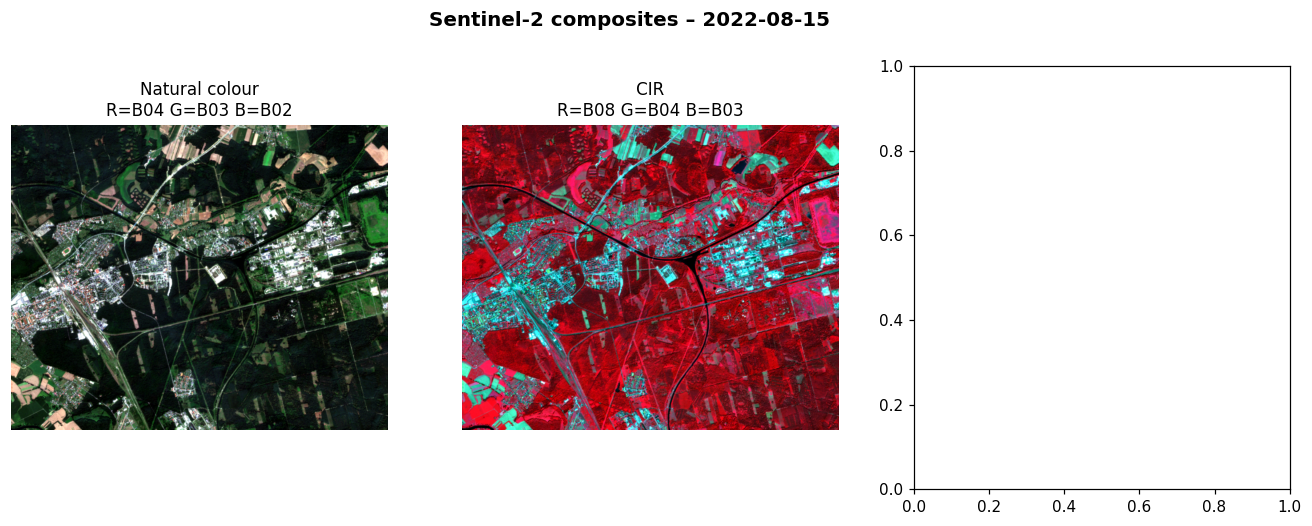

In [15]:
def stretch(arr, pct=(2, 98)):
    lo, hi = np.nanpercentile(arr, pct)
    return np.clip((arr - lo) / max(hi - lo, 1e-9), 0, 1)


def s2_get_band(band_name: str, target_shape=None) -> np.ndarray:
    """Return a band array, resampling to target_shape if necessary (bilinear)."""
    data = s2_refl[band_name]
    if target_shape is not None and data.shape != target_shape:
        data = nd_zoom(data, (target_shape[0] / data.shape[0],
                              target_shape[1] / data.shape[1]), order=1)
    return data


# Reference shape = first 10 m band available
_S2_10M_SHAPE = s2_refl['B04'].shape


def s2_rgb(r_band, g_band, b_band):
    """Stack three S2 bands into an RGB array, upsampling 20 m bands as needed."""
    r = stretch(s2_get_band(r_band, _S2_10M_SHAPE))
    g = stretch(s2_get_band(g_band, _S2_10M_SHAPE))
    b = stretch(s2_get_band(b_band, _S2_10M_SHAPE))
    return np.dstack([r, g, b])


S2_COMPOSITES = [
    ('Natural colour',    'B04', 'B03', 'B02'),
    ('CIR',              'B08', 'B04', 'B03'),
    ('Water enhancement', 'B05', 'B03', 'B02'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(f'Sentinel-2 composites – {best_date}', fontsize=13, fontweight='bold')

for ax, (title, r, g, b) in zip(axes, S2_COMPOSITES):
    ax.imshow(np.nan_to_num(s2_rgb(r, g, b)), interpolation='bilinear')
    ax.set_title(f'{title}\nR={r} G={g} B={b}')
    ax.axis('off')

fig.tight_layout()
fig.savefig(OUT_DIR / 's2_composites.png', bbox_inches='tight', dpi=130)
plt.show()


### 5.2 Sentinel-2 Water Mask

We combine the SCL water class (value 6) with an NDWI threshold.

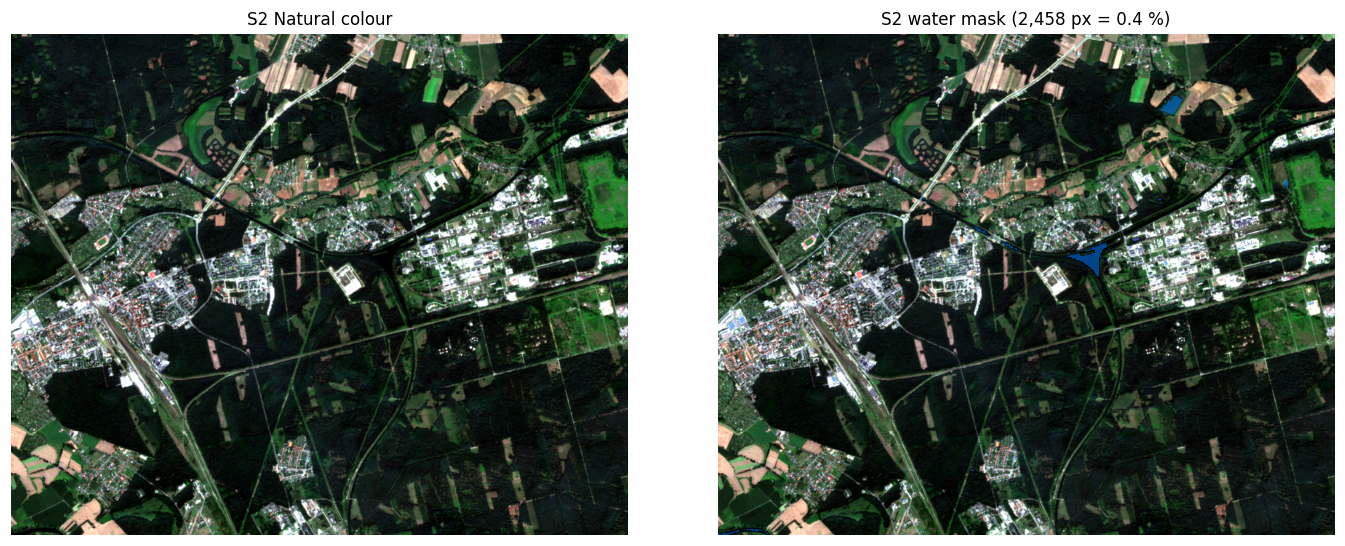

In [16]:
# SCL class 6 = water; also accept class 5 (unclassified, common in rivers)
scl_water = np.isin(scl, [6])

ndwi_s2 = (s2_refl['B03'] - s2_refl['B08']) / (s2_refl['B03'] + s2_refl['B08'] + 1e-9)
ndwi_water = ndwi_s2 > 0.0

# SCL-based mask is primary; NDWI fills gaps
# Resize the 20 m SCL to 10 m grid by nearest-neighbour (2× upscale)
from scipy.ndimage import zoom as nd_zoom

h_ref, w_ref = s2_refl['B04'].shape
h_scl, w_scl = scl_water.shape

if (h_scl, w_scl) != (h_ref, w_ref):
    zoom_r = h_ref / h_scl
    zoom_c = w_ref / w_scl
    scl_water_up = nd_zoom(scl_water.astype(np.float32), (zoom_r, zoom_c), order=0).astype(bool)
else:
    scl_water_up = scl_water

s2_water_mask = scl_water_up | ndwi_water
s2_water_mask &= np.isfinite(s2_refl['B04'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
nc = np.nan_to_num(s2_rgb('B04', 'B03', 'B02'))
ax1.imshow(nc, interpolation='bilinear')
ax1.set_title('S2 Natural colour')
ax1.axis('off')

overlay = np.zeros((*s2_water_mask.shape, 4), dtype=np.float32)
overlay[s2_water_mask] = [0.0, 0.5, 1.0, 0.55]
ax2.imshow(nc, interpolation='bilinear')
ax2.imshow(overlay)
ax2.set_title(f'S2 water mask ({s2_water_mask.sum():,} px = {s2_water_mask.mean()*100:.1f} %)')
ax2.axis('off')

fig.tight_layout()
fig.savefig(OUT_DIR / 's2_water_mask.png', bbox_inches='tight', dpi=130)
plt.show()

## 6. Water Quality Indices – Sentinel-2

The same family of indices, adapted to Sentinel-2 band positions:

| Index | Hyperspectral | Sentinel-2 | Note |
|-------|--------------|------------|------|
| Chl-a NDCI | (R709 − R665)/(R709 + R665) | (B05 − B04)/(B05 + B04) | B05 ≈ 705 nm |
| Chl-a 3BA | (1/R665 − 1/R709)·R754 | (1/B04 − 1/B05)·B07 | B07 ≈ 783 nm |
| CDOM proxy | R443/R665 | B02/B04 | B02 ≈ 490 nm |
| Turbidity NDTI | (R665 − R560)/(R665 + R560) | (B04 − B03)/(B04 + B03) | |

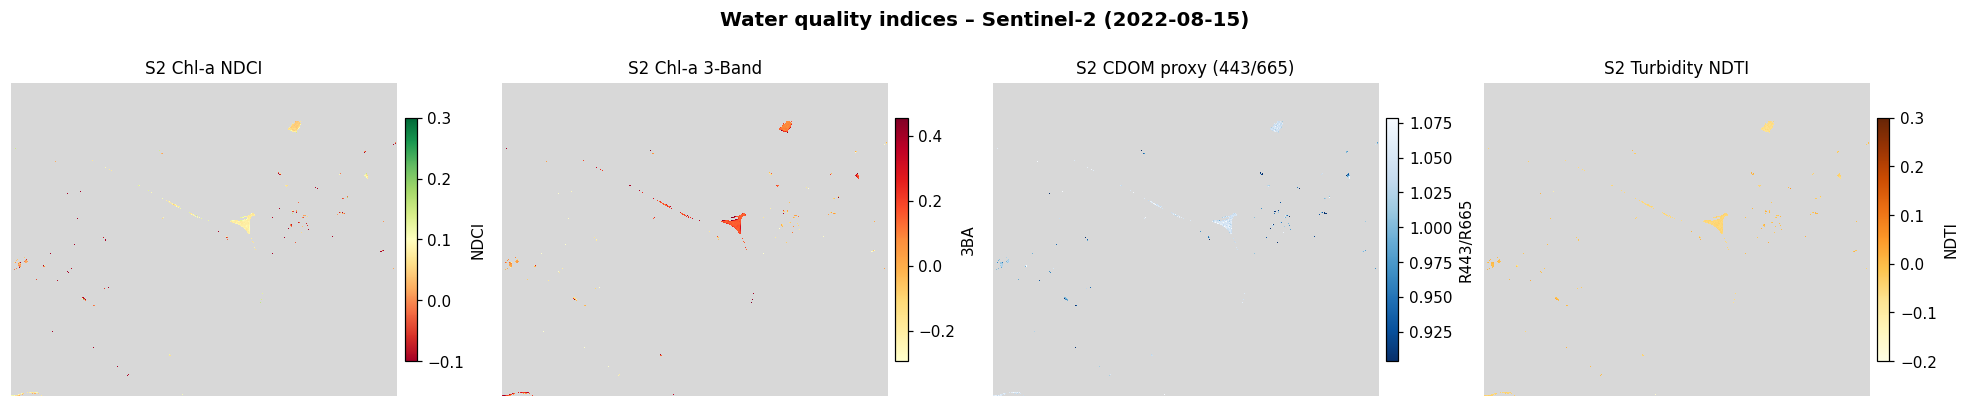

In [17]:
# Resample 20 m bands (B05, B06, B07) to 10 m grid for index computation
def resample_to_10m(band_20m, target_shape):
    h, w = target_shape
    h0, w0 = band_20m.shape
    if (h0, w0) == (h, w):
        return band_20m
    return nd_zoom(band_20m, (h / h0, w / w0), order=1)   # bilinear


shape_10m = s2_refl['B04'].shape

B02 = s2_refl['B02']
B03 = s2_refl['B03']
B04 = s2_refl['B04']
B05 = resample_to_10m(s2_refl['B05'], shape_10m)
B07 = resample_to_10m(s2_refl['B07'], shape_10m)

# ── compute indices ───────────────────────────────────────────────────────────
s2_ndci = (B05 - B04) / (B05 + B04 + 1e-9)
s2_ba3  = (1.0 / (B04 + 1e-9) - 1.0 / (B05 + 1e-9)) * B07
s2_cdom = B02 / (B04 + 1e-9)
s2_ndti = (B04 - B03) / (B04 + B03 + 1e-9)

s2_indices = dict(ndci=s2_ndci, ba3=s2_ba3, cdom=s2_cdom, ndti=s2_ndti)

# ── visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f'Water quality indices – Sentinel-2 ({best_date})',
             fontsize=13, fontweight='bold')

for ax, (key, title, cmap, vmin, vmax, clabel) in zip(axes, INDEX_CONFIGS):
    plot_index_map(ax, s2_indices[key], s2_water_mask, f'S2 {title}',
                  cmap, vmin, vmax, clabel)

fig.tight_layout()
fig.savefig(OUT_DIR / 'wq_indices_s2.png', bbox_inches='tight', dpi=130)
plt.show()

## 7. Comparison: Airborne vs. Sentinel-2

### 7.1 Statistical comparison

In [18]:
# ── aggregate S2 water quality statistics ─────────────────────────────────────
rows_s2 = []
for key, label, *_ in INDEX_CONFIGS:
    vals = s2_indices[key][s2_water_mask]
    vals = vals[np.isfinite(vals)]
    rows_s2.append(dict(
        sensor='Sentinel-2', index=label,
        mean=np.mean(vals), std=np.std(vals),
        p5=np.percentile(vals, 5), p95=np.percentile(vals, 95),
        n=len(vals),
    ))

rows_hs = []
# Use combined mask for block_008 as representative
block = blocks['block_008']
for key, label, *_ in INDEX_CONFIGS:
    vals = block['hs_indices'][key][block['water_mask']]
    vals = vals[np.isfinite(vals)]
    rows_hs.append(dict(
        sensor='Airborne HS (block_008)', index=label,
        mean=np.mean(vals), std=np.std(vals),
        p5=np.percentile(vals, 5), p95=np.percentile(vals, 95),
        n=len(vals),
    ))

df_compare = pd.DataFrame(rows_hs + rows_s2).round(4)
df_compare

,sensor,index,mean,std,p5,p95,n
0,Airborne HS (block_008),Chl-a NDCI,-0.0424,0.0366,-0.0801,0.0361,467497
1,Airborne HS (block_008),Chl-a 3-Band,-0.0508,0.0666,-0.0951,0.0731,467497
2,Airborne HS (block_008),CDOM proxy (443/665),0.4887,0.1736,0.3698,0.8549,467497
3,Airborne HS (block_008),Turbidity NDTI,0.0193,0.0927,-0.1828,0.0873,467497
4,Sentinel-2,Chl-a NDCI,0.0477,0.0654,-0.0988,0.1179,2458
5,Sentinel-2,Chl-a 3-Band,0.1187,0.1589,-0.1877,0.3659,2458
6,Sentinel-2,CDOM proxy (443/665),1.0309,0.0452,0.9297,1.0707,2458
7,Sentinel-2,Turbidity NDTI,-0.0416,0.0242,-0.0715,0.0057,2458


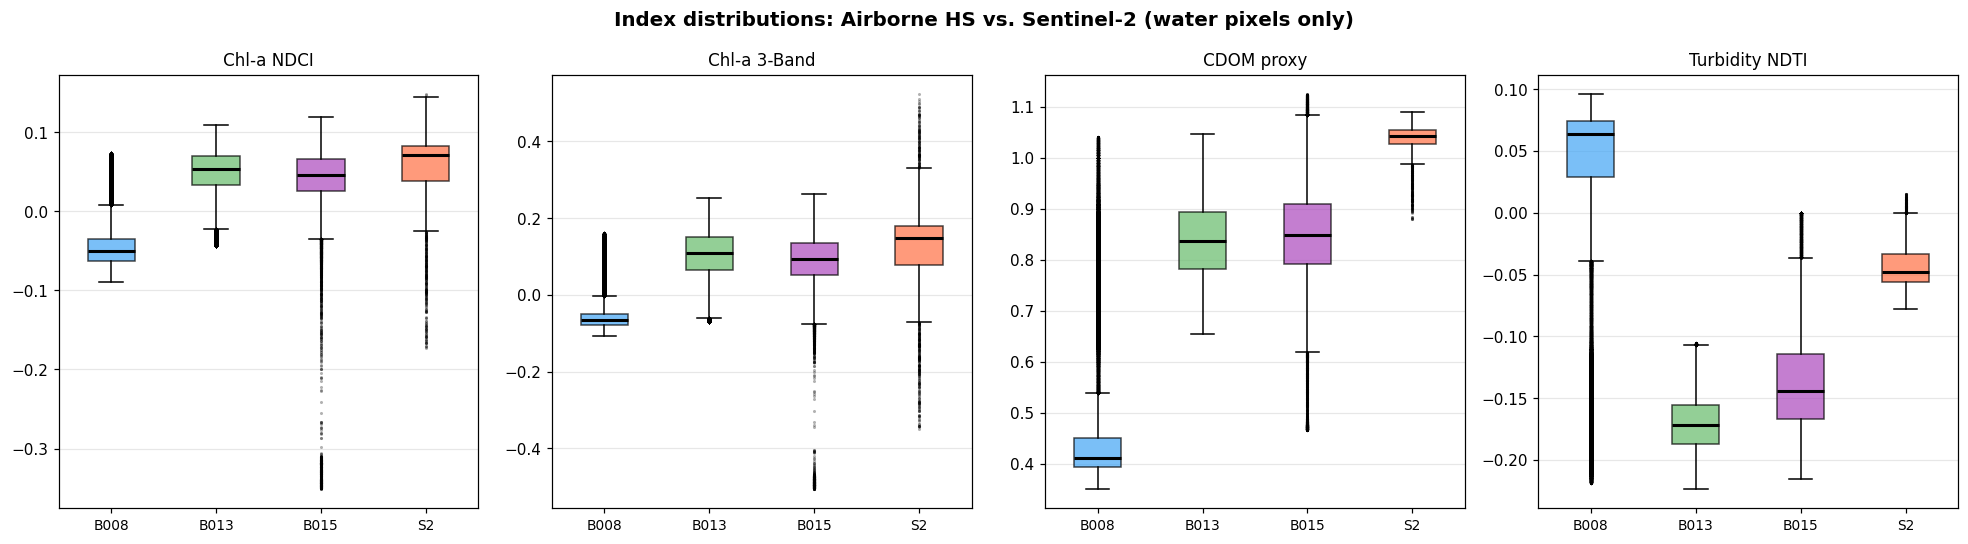

In [19]:
# ── box plots: index distribution comparison ──────────────────────────────────
index_keys = ['ndci', 'ba3', 'cdom', 'ndti']
index_labels = ['Chl-a NDCI', 'Chl-a 3-Band', 'CDOM proxy', 'Turbidity NDTI']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Index distributions: Airborne HS vs. Sentinel-2 (water pixels only)',
             fontsize=13, fontweight='bold')

colors = ['#2196F3', '#FF9800']

for ax, key, label in zip(axes, index_keys, index_labels):
    datasets = []
    group_labels = []
    
    # All hyperspectral blocks
    for block_name, block in blocks.items():
        vals = block['hs_indices'][key][block['water_mask']]
        vals = vals[np.isfinite(vals)]
        # Clip outliers to 1st–99th percentile
        lo, hi = np.percentile(vals, [1, 99])
        datasets.append(vals[(vals >= lo) & (vals <= hi)])
        group_labels.append(block_name.replace('block_', 'B'))

    # Sentinel-2
    vals_s2 = s2_indices[key][s2_water_mask]
    vals_s2 = vals_s2[np.isfinite(vals_s2)]
    lo, hi = np.percentile(vals_s2, [1, 99])
    datasets.append(vals_s2[(vals_s2 >= lo) & (vals_s2 <= hi)])
    group_labels.append('S2')

    bp = ax.boxplot(datasets, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))

    palette = ['#42A5F5', '#66BB6A', '#AB47BC', '#FF7043']
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_xticks(range(1, len(group_labels) + 1))
    ax.set_xticklabels(group_labels, fontsize=9)
    ax.set_title(label)
    ax.grid(True, alpha=0.3, axis='y')

fig.tight_layout()
fig.savefig(OUT_DIR / 'comparison_boxplots.png', bbox_inches='tight', dpi=130)
plt.show()

### 7.2 Spatial upscaling comparison

We spatially degrade the hyperspectral index maps to the Sentinel-2 10 m / 20 m resolution  
and compare them side by side.

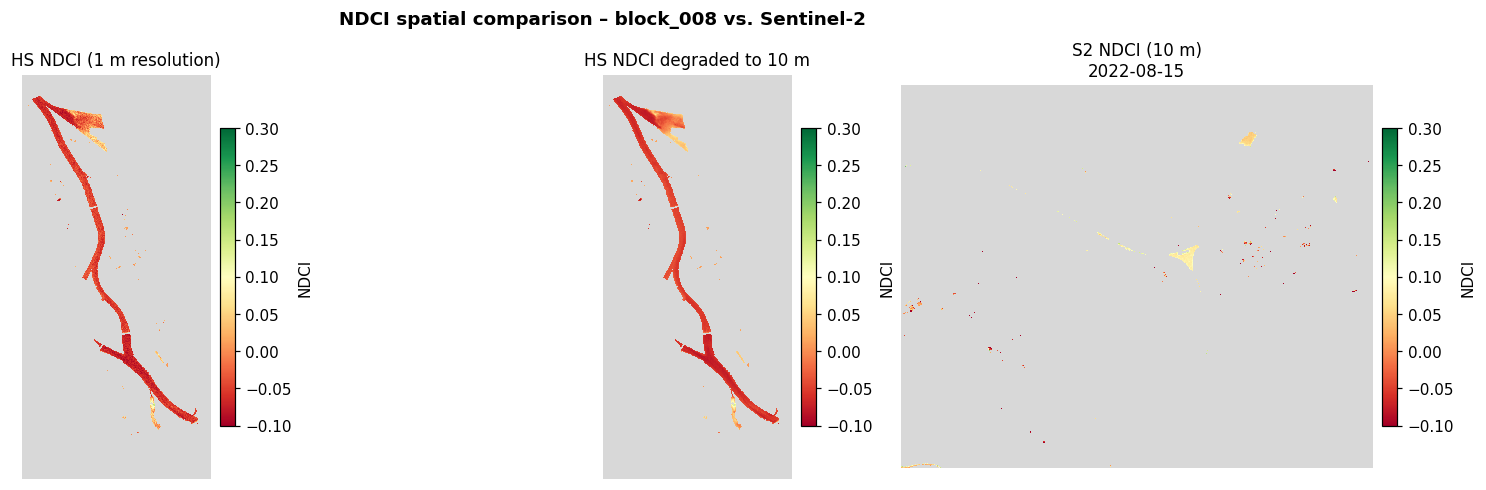

In [20]:
from scipy.ndimage import uniform_filter

def degrade_to_s2_resolution(data, mask, pixel_size_m=1.0, target_res_m=10.0):
    """
    Average the 1 m hyperspectral index to simulate S2 10 m resolution.
    Returns the degraded array (same shape, but spatially smoothed).
    """
    k = int(round(target_res_m / pixel_size_m))
    filled = np.where(mask & np.isfinite(data), data, 0.0)
    count  = np.where(mask & np.isfinite(data), 1.0, 0.0)
    smooth_sum = uniform_filter(filled, size=k)
    smooth_cnt = uniform_filter(count,  size=k)
    with np.errstate(invalid='ignore', divide='ignore'):
        result = np.where(smooth_cnt > 0.1, smooth_sum / smooth_cnt, np.nan)
    return result


# Compare block_008 NDCI degraded vs S2 NDCI (side by side)
block = blocks['block_008']
hs_ndci_degraded = degrade_to_s2_resolution(
    block['hs_indices']['ndci'], block['water_mask'], target_res_m=10.0
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('NDCI spatial comparison – block_008 vs. Sentinel-2', fontweight='bold')

vmin, vmax = -0.1, 0.3

ax = axes[0]
plot_index_map(ax, block['hs_indices']['ndci'], block['water_mask'],
               'HS NDCI (1 m resolution)', 'RdYlGn', vmin, vmax, 'NDCI')

ax = axes[1]
plot_index_map(ax, hs_ndci_degraded, block['water_mask'],
               'HS NDCI degraded to 10 m', 'RdYlGn', vmin, vmax, 'NDCI')

ax = axes[2]
plot_index_map(ax, s2_indices['ndci'], s2_water_mask,
               f'S2 NDCI (10 m)\n{best_date}', 'RdYlGn', vmin, vmax, 'NDCI')

fig.tight_layout()
fig.savefig(OUT_DIR / 'ndci_spatial_comparison.png', bbox_inches='tight', dpi=130)
plt.show()

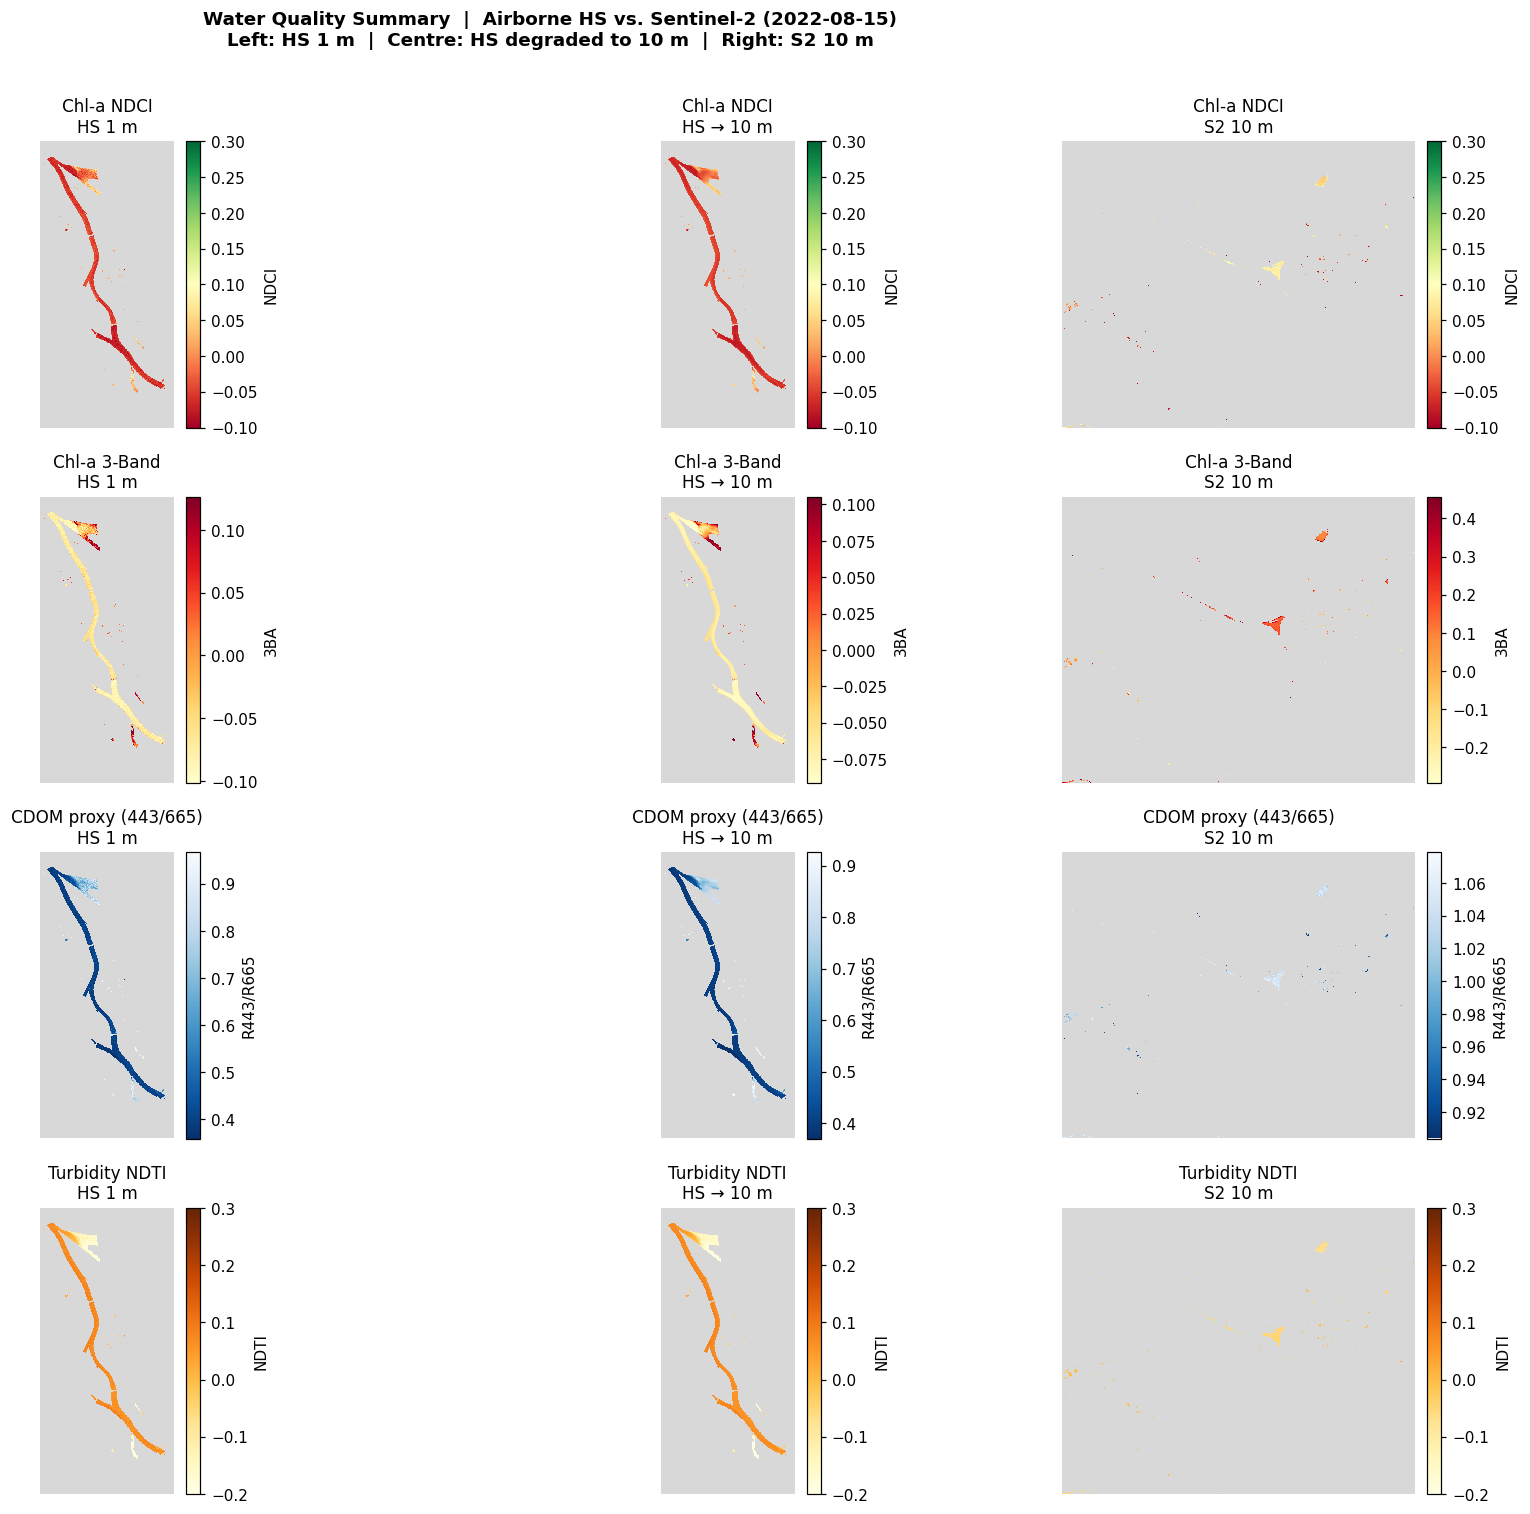

In [25]:
# ── Summary dashboard: all four indices, HS 1 m | HS 10 m | S2 ─────────────────
fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    f'Water Quality Summary  |  Airborne HS vs. Sentinel-2 ({best_date})\n'
    'Left: HS 1 m  |  Centre: HS degraded to 10 m  |  Right: S2 10 m',
    fontsize=12, fontweight='bold',
)

rows_fig = []
for key, title, cmap, vmin, vmax, clabel in INDEX_CONFIGS:
    hs_idx  = block['hs_indices'][key]
    hs_mask = block['water_mask']
    hs_deg  = degrade_to_s2_resolution(hs_idx, hs_mask, target_res_m=10.0)
    rows_fig.append((key, title, cmap, vmin, vmax, clabel, hs_idx, hs_mask, hs_deg))

for row_i, (key, title, cmap, vmin, vmax, clabel, hs_idx, hs_mask, hs_deg) in enumerate(rows_fig):
    ax1 = fig.add_subplot(4, 3, row_i * 3 + 1)
    ax2 = fig.add_subplot(4, 3, row_i * 3 + 2)
    ax3 = fig.add_subplot(4, 3, row_i * 3 + 3)

    plot_index_map(ax1, hs_idx,             hs_mask,      f'{title}\nHS 1 m',        cmap, vmin, vmax, clabel)
    plot_index_map(ax2, hs_deg,             hs_mask,      f'{title}\nHS → 10 m',     cmap, vmin, vmax, clabel)
    plot_index_map(ax3, s2_indices[key],    s2_water_mask, f'{title}\nS2 10 m',       cmap, vmin, vmax, clabel)

fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(OUT_DIR / 'wq_summary_dashboard.png', bbox_inches='tight', dpi=110)
plt.show()

### 7.3 Scatter plot: HS (degraded) vs. S2

To directly compare the two sensors we need to reproject one dataset to the other's grid.  
Here we project the HS-derived index (spatially degraded to 10 m) onto the S2 grid using `rasterio.warp`.

In [27]:
def reproject_hs_to_s2_grid(hs_data, hs_origin, hs_pixel=1.0,
                              s2_profile=None) -> np.ndarray:
    """
    Reproject a 2-D hyperspectral-derived raster (CS2000 Zone 6)
    onto the Sentinel-2 10 m grid (same CRS as s2_profile).
    """
    nrows, ncols = hs_data.shape
    src_crs = CRS.from_epsg(EPSG_LOCAL)
    dst_crs = s2_profile['crs']

    # Bounding box of the HS raster (pixel-edge coordinates)
    left   = hs_origin[0]
    top    = hs_origin[1]
    right  = left + ncols * hs_pixel
    bottom = top  - nrows * hs_pixel

    dst_transform, dst_width, dst_height = calculate_default_transform(
        src_crs, dst_crs, ncols, nrows,
        left=left, bottom=bottom, right=right, top=top,
    )

    dst = np.full((dst_height, dst_width), np.nan, dtype=np.float32)

    src_transform = rasterio.transform.from_bounds(
        left, bottom, right, top, ncols, nrows
    )

    reproject(
        source=hs_data.astype(np.float32),
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.average,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst


# Reproject block_008 degraded NDCI onto S2 grid
hs_ndci_s2grid = reproject_hs_to_s2_grid(
    hs_ndci_degraded,
    hs_origin=block['origin'],
    s2_profile=s2_profiles['B04'],
)

# Resize to match S2 shape exactly
if hs_ndci_s2grid.shape != s2_ndci.shape:
    hs_ndci_s2grid = nd_zoom(
        hs_ndci_s2grid,
        (s2_ndci.shape[0] / hs_ndci_s2grid.shape[0],
         s2_ndci.shape[1] / hs_ndci_s2grid.shape[1]),
        order=1,
    )

print(f'Reprojected HS shape: {hs_ndci_s2grid.shape}  S2 shape: {s2_ndci.shape}')


Reprojected HS shape: (689, 848)  S2 shape: (689, 848)


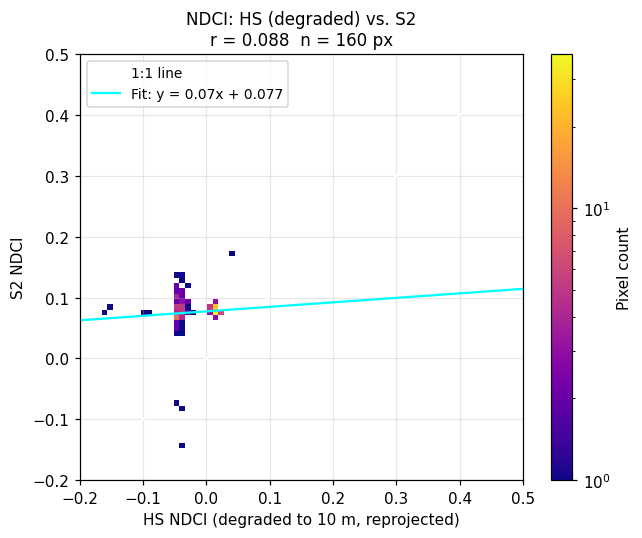

In [28]:
# Scatter plot: HS NDCI (degraded, reprojected) vs. S2 NDCI
common_mask = s2_water_mask & np.isfinite(hs_ndci_s2grid) & np.isfinite(s2_ndci)

x = hs_ndci_s2grid[common_mask]
y = s2_ndci[common_mask]

fig, ax = plt.subplots(figsize=(6, 5))

h = ax.hist2d(x, y, bins=80, norm=mcolors.LogNorm(),
              cmap='plasma', range=[[-0.2, 0.5], [-0.2, 0.5]])
plt.colorbar(h[3], ax=ax, label='Pixel count')

# 1:1 line
lim = (-0.2, 0.5)
ax.plot(lim, lim, 'w--', linewidth=1.5, label='1:1 line')

# Regression line
finite = np.isfinite(x) & np.isfinite(y)
if finite.sum() > 2:
    m, b = np.polyfit(x[finite], y[finite], 1)
    xs = np.linspace(*lim, 100)
    ax.plot(xs, m * xs + b, 'cyan', linewidth=1.5,
            label=f'Fit: y = {m:.2f}x + {b:.3f}')
    corr = np.corrcoef(x[finite], y[finite])[0, 1]
    ax.set_title(f'NDCI: HS (degraded) vs. S2\nr = {corr:.3f}  n = {finite.sum():,} px')

ax.set_xlabel('HS NDCI (degraded to 10 m, reprojected)')
ax.set_ylabel('S2 NDCI')
ax.set_xlim(*lim)
ax.set_ylim(*lim)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR / 'ndci_scatter_hs_vs_s2.png', bbox_inches='tight', dpi=130)
plt.show()

## 8. Discussion

### Resolution & spatial detail
- The airborne hyperspectral sensor provides **1 m GSD**, capturing fine-scale features  
  (mixing zones, shoreline gradients, boat wakes) invisible to Sentinel-2 (10–20 m).
- After spatial degradation to 10 m the HS indices become spatially compatible  
  with the S2 estimates, but fine heterogeneity is lost.

### Spectral resolution  
- With 456 bands the airborne sensor resolves narrow chlorophyll absorption/fluorescence features,  
  allowing the 3-band algorithm and precise placement of the red-edge peak.  
- Sentinel-2 has only 6 relevant bands (B02–B08A), but the band positions  
  were specifically designed to support water-colour products.

### Temporal difference  
- Any systematic offset between HS and S2 indices partly reflects the  
  **temporal gap** (Δ days) between flights: water quality in the Odra can change  
  rapidly due to flow events, algal dynamics, or pollution inputs.

### Practical takeaways  
| Aspect | Airborne HS | Sentinel-2 |
|--------|-------------|------------|
| Spatial resolution | 1 m | 10–20 m |
| Spectral resolution | ~3 nm / 456 bands | 6–8 bands |
| Temporal frequency | Campaign-based | ≤ 5 days |
| Area coverage | Local transects | Regional / global |
| Cost / access | High | Free (open data) |

In [29]:
print('All outputs saved to:', OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob('*.png')):
    print(' ', f.name)

All outputs saved to: /Users/michalkawa/space-tech/remote-sensing/eolabs/lab_5/outputs
  comparison_boxplots.png
  composites_block_008.png
  composites_block_013.png
  composites_block_015.png
  ndci_scatter_hs_vs_s2.png
  ndci_spatial_comparison.png
  s2_water_mask.png
  water_mask_block_008.png
  water_mask_block_013.png
  water_mask_block_015.png
  wq_indices_hs_block_008.png
  wq_indices_hs_block_013.png
  wq_indices_hs_block_015.png
  wq_indices_s2.png
  wq_summary_dashboard.png
